# StreamView Analytics — Análisis del catálogo de películas y series
**Asignatura:** ADY1104 Visualización de Datos · Evaluación Parcial 1

### Problema de negocio
StreamView Analytics quiere entender qué contenido de su catálogo es mejor evaluado, para tomar decisiones sobre qué géneros priorizar en adquisiciones y recomendaciones. La idea es que un usuario que entra a la plataforma encuentre contenido de buena calidad más rápido, lo que debería ayudar a la retención.

### Audiencia objetivo
El equipo de **contenidos y adquisiciones** de StreamView. No son necesariamente técnicos, así que los gráficos tienen que leerse rápido y dejar clara la conclusión sin tener que explicar mucha estadística.

### Objetivo del análisis
1. Ver qué géneros tienen mejores calificaciones y cuáles son más consistentes.
2. Identificar qué géneros tienen más probabilidad de tener títulos bien evaluados.
3. Comparar películas y series, y ver cómo cambian las calificaciones en el tiempo.

### Nota sobre los datos
El dataset es de **catálogo** (títulos, géneros, año, votos), no trae datos de usuarios, reproducciones ni suscripciones. Por eso usamos el **rating** (promedio de votos de 0 a 10) como aproximación a la satisfacción del usuario.

# 1. Librerías y configuración

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Busca la carpeta data/ tanto si el notebook se abre desde notebooks/ como desde la raíz del proyecto
RAIZ = '..' if os.path.isdir(os.path.join('..', 'data')) else '.'
DATA_DIR = os.path.join(RAIZ, 'data') if os.path.isdir(os.path.join(RAIZ, 'data')) else '.'
IMG_DIR = os.path.join(RAIZ, 'images')
os.makedirs(IMG_DIR, exist_ok=True)

# Paleta: gris para el contexto y color solo para lo que queremos destacar
GRIS = '#B8B8B8'
DESTACADO_BUENO = '#2A9D8F'
DESTACADO_MALO = '#E76F51'


def fmt(numero, decimales=0):
    """Formato chileno: punto para los miles y coma para los decimales."""
    texto = f'{numero:,.{decimales}f}'
    return texto.replace(',', 'X').replace('.', ',').replace('X', '.')

# 2. Carga de datos

In [2]:
df_movies = pd.read_csv(os.path.join(DATA_DIR, 'netflix_movies_detailed_up_to_2025.csv'))
df_shows = pd.read_csv(os.path.join(DATA_DIR, 'netflix_tv_shows_detailed_up_to_2025.csv'))

print(f'Películas: {fmt(df_movies.shape[0])} filas, {df_movies.shape[1]} columnas')
print(f'Series:    {fmt(df_shows.shape[0])} filas, {df_shows.shape[1]} columnas')

Películas: 16.000 filas, 18 columnas
Series:    16.000 filas, 16 columnas


In [3]:
df_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [4]:
df_shows.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600
3,75685,TV Show,Prostřeno!,NaN,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,1 Seasons,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500
4,33847,TV Show,The Talk,NaN,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,1 Seasons,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400


### Variables relevantes para el análisis
| Variable | Descripción | Uso |
|---|---|---|
| `title` | Nombre del título | Identificación |
| `type` | Movie / TV Show | Comparar películas vs series |
| `genres` | Géneros (pueden ser varios separados por coma) | Análisis por género |
| `release_year` | Año de estreno (2010–2025) | Tendencia en el tiempo |
| `rating` | Promedio de votos, escala 0–10 | Métrica principal de calidad percibida |
| `vote_count` | Cantidad de votos | Filtrar ratings poco confiables |
| `popularity`, `language`, `country` | Popularidad, idioma y país | Filtros para el dashboard |

# 3. Exploración preliminar

In [5]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [6]:
df_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      5035 non-null   object 
 4   cast          14843 non-null  object 
 5   country       14203 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        15026 non-null  object 
 11  language      16000 non-null  object 
 12  description   12794 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
dtypes: float64(3), int64(3), object(10)
memory usage: 2.0+ MB


In [7]:
df_movies.describe()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,0.0,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2017.500000,5.956368,NaN,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,4.609916,1.754741,NaN,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,2010.000000,0.000000,NaN,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,2013.750000,5.600000,NaN,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,2017.500000,6.300000,NaN,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,2021.250000,6.923000,NaN,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,2025.000000,10.000000,NaN,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


In [8]:
df_shows.describe()

,show_id,release_year,rating,popularity,vote_count,vote_average
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,126567.673375,2017.500000,5.417107,64.850984,107.014313,5.417107
std,75640.760545,4.609916,3.266492,139.387289,607.461581,3.266492
min,767.000000,2010.000000,0.000000,2.323000,0.000000,0.000000
25%,67867.750000,2013.750000,2.700000,24.874750,1.000000,2.700000
50%,94380.500000,2017.500000,6.800000,36.187500,4.000000,6.800000
75%,206920.750000,2021.250000,7.800000,62.187500,30.000000,7.800000
max,285345.000000,2025.000000,10.000000,6421.923000,24664.000000,10.000000


## 3.1 Problemas detectados

In [9]:
print('--- Valores faltantes (películas) ---')
faltantes_m = df_movies.isnull().sum()
print(faltantes_m[faltantes_m > 0])

print('\n--- Valores faltantes (series) ---')
faltantes_s = df_shows.isnull().sum()
print(faltantes_s[faltantes_s > 0])

--- Valores faltantes (películas) ---
director         132
cast             204
country          466
duration       16000
genres           107
description      132
dtype: int64

--- Valores faltantes (series) ---
director       10965
cast            1157
country         1797
genres           974
description     3206
dtype: int64


In [10]:
print(f'Duplicados por show_id -> películas: {fmt(df_movies.duplicated(subset=["show_id"]).sum())}, '
      f'series: {fmt(df_shows.duplicated(subset=["show_id"]).sum())}')

print(f'Ratings en 0 -> películas: {fmt((df_movies["rating"] == 0).sum())}, '
      f'series: {fmt((df_shows["rating"] == 0).sum())}')

print(f'Películas con menos de 10 votos: {fmt((df_movies["vote_count"] < 10).sum())}')

Duplicados por show_id -> películas: 0, series: 9
Ratings en 0 -> películas: 899, series: 3.673
Películas con menos de 10 votos: 1.817


In [11]:
# Revisiones extra sobre la estructura del dataset
print('¿rating es igual a vote_average?')
print(f'  películas: {(df_movies["rating"] == df_movies["vote_average"]).all()}, '
      f'series: {(df_shows["rating"] == df_shows["vote_average"]).all()}')

fecha = pd.to_datetime(df_movies['date_added'], errors='coerce')
print(f'¿El año de date_added coincide con release_year? {fmt((fecha.dt.year == df_movies["release_year"]).mean() * 100)}%')

print('\nTítulos por año de estreno (películas):')
print(df_movies['release_year'].value_counts().sort_index().to_dict())

¿rating es igual a vote_average?
  películas: True, series: True
¿El año de date_added coincide con release_year? 100%

Títulos por año de estreno (películas):
{2010: 1000, 2011: 1000, 2012: 1000, 2013: 1000, 2014: 1000, 2015: 1000, 2016: 1000, 2017: 1000, 2018: 1000, 2019: 1000, 2020: 1000, 2021: 1000, 2022: 1000, 2023: 1000, 2024: 1000, 2025: 1000}


**Lo que encontramos:**
- **Duplicados:** no hay filas repetidas completas, pero en series hay 9 `show_id` repetidos, que eliminamos.
- **Ratings en 0:** 899 películas y 3.673 series (23% de las series) tienen rating 0. No es que sean malísimas, son títulos sin votos, así que se tratan como dato faltante.
- **Pocos votos:** hay títulos con 1 o 2 votos que aparecen con rating 10 o 1. Eso no es representativo y genera outliers.
- **`rating` y `vote_average` son la misma columna**, así que usamos solo `rating`.
- **`date_added` coincide con el año de estreno**, no sirve para saber cuándo se agregó un título al catálogo.
- **Hay exactamente 1.000 títulos por año**, o sea que el dataset es una muestra balanceada. No se puede concluir nada sobre si el catálogo crece o no.
- **`duration` está vacía en películas** y `budget`/`revenue` tienen muchos faltantes, así que no las usamos.

# 4. Limpieza de datos

In [12]:
# 1) Fechas a datetime
for df in (df_movies, df_shows):
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 2) Rating 0 = sin votos -> NaN (en películas Y en series)
df_movies.loc[df_movies['rating'] == 0, 'rating'] = np.nan
df_shows.loc[df_shows['rating'] == 0, 'rating'] = np.nan

# budget y revenue en 0 también son faltantes
df_movies.loc[df_movies['budget'] == 0, 'budget'] = np.nan
df_movies.loc[df_movies['revenue'] == 0, 'revenue'] = np.nan

# 3) Filas sin título y duplicados
df_movies = df_movies.dropna(subset=['title']).drop_duplicates(subset=['show_id'])
df_shows = df_shows.dropna(subset=['title']).drop_duplicates(subset=['show_id'])

# 4) Columnas que no aportan (vacías o repetidas)
df_movies = df_movies.drop(columns=['duration', 'vote_average'])
df_shows = df_shows.drop(columns=['vote_average'])

### Filtro de confiabilidad: mínimo 50 votos
Para los gráficos de calificación solo consideramos títulos con **50 votos o más**. Con menos votos el promedio depende de muy pocas personas y cualquier título puede quedar en 1 o en 10 por casualidad.
Elegimos 50 porque en películas deja fuera solo a los títulos más desconocidos y conserva la mayoría de los datos.

In [13]:
MIN_VOTOS = 50

movies_an = df_movies[(df_movies['vote_count'] >= MIN_VOTOS) & df_movies['rating'].notna()].copy()
shows_an = df_shows[(df_shows['vote_count'] >= MIN_VOTOS) & df_shows['rating'].notna()].copy()

print(f'Películas para análisis: {fmt(len(movies_an))} de {fmt(len(df_movies))} ({fmt(len(movies_an)/len(df_movies) * 100)}%)')
print(f'Series para análisis:    {fmt(len(shows_an))} de {fmt(len(df_shows))} ({fmt(len(shows_an)/len(df_shows) * 100)}%)')

Películas para análisis: 12.185 de 16.000 (76%)
Series para análisis:    3.212 de 15.991 (20%)


### Datos limpios

In [14]:
for nombre, df in [('PELÍCULAS', df_movies), ('SERIES', df_shows)]:
    print(f'---------- {nombre} ----------')
    print(f'Filas: {fmt(df.shape[0])}, columnas: {df.shape[1]}')
    print(f'Duplicados: {fmt(df.duplicated(subset=["show_id"]).sum())}')
    print(f'Títulos faltantes: {fmt(df["title"].isnull().sum())}')
    print(f'Ratings en 0: {fmt((df["rating"] == 0).sum())}')
    print(f'Tipo de date_added: {df["date_added"].dtype}\n')

---------- PELÍCULAS ----------
Filas: 16.000, columnas: 16
Duplicados: 0
Títulos faltantes: 0
Ratings en 0: 0
Tipo de date_added: datetime64[ns]

---------- SERIES ----------
Filas: 15.991, columnas: 15
Duplicados: 0
Títulos faltantes: 0
Ratings en 0: 0
Tipo de date_added: datetime64[ns]



# 5. Preparación de géneros
Cada película puede tener varios géneros en la misma celda (por ejemplo `"Drama, Romance"`). Separamos por coma y usamos `explode` para que cada género quede en su propia fila. Así una película de Drama y Romance cuenta en los dos géneros.

In [15]:
movies_genres = movies_an[movies_an['genres'].notna()].copy()
movies_genres['genres'] = movies_genres['genres'].str.split(', ')
movies_genres = movies_genres.explode('genres')

print(f'Géneros distintos: {fmt(movies_genres["genres"].nunique())}')
print(sorted(movies_genres['genres'].unique()))

Géneros distintos: 19


['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [16]:
# Traducción para que los gráficos queden en español
TRADUCCION = {
    'Drama': 'Drama', 'Comedy': 'Comedia', 'Thriller': 'Suspenso', 'Action': 'Acción',
    'Horror': 'Terror', 'Romance': 'Romance', 'Crime': 'Crimen', 'Adventure': 'Aventura',
    'Animation': 'Animación', 'Family': 'Familia', 'Science Fiction': 'Ciencia ficción',
    'Fantasy': 'Fantasía', 'Documentary': 'Documental', 'Mystery': 'Misterio',
    'History': 'Historia', 'Music': 'Música', 'War': 'Bélico', 'Western': 'Western',
    'TV Movie': 'Película de TV',
}
movies_genres['genero'] = movies_genres['genres'].map(TRADUCCION).fillna(movies_genres['genres'])

# Top 10 géneros con más películas
top_generos = movies_genres['genero'].value_counts().head(10).index
df_top = movies_genres[movies_genres['genero'].isin(top_generos)]

resumen = (df_top.groupby('genero')['rating']
           .agg(n='count',
                mediana='median',
                q1=lambda x: x.quantile(0.25),
                q3=lambda x: x.quantile(0.75),
                pct_7_o_mas=lambda x: (x >= 7).mean() * 100)
           .sort_values('mediana', ascending=False))
resumen['iqr'] = resumen['q3'] - resumen['q1']
resumen.round(2)

,n,mediana,q1,q3,pct_7_o_mas,iqr
genero,,,,,,
Animación,1226,7.04,6.60,7.50,54.98,0.90
Familia,1206,6.78,6.20,7.20,38.72,1.00
Drama,5311,6.60,6.10,7.10,31.86,1.00
Aventura,1484,6.60,6.00,7.20,33.42,1.20
Romance,1745,6.50,6.00,7.03,29.05,1.03
Crimen,1491,6.40,5.90,6.90,22.74,1.00
Acción,2667,6.34,5.80,6.90,22.53,1.10
Comedia,3790,6.34,5.80,6.90,22.69,1.10
Suspenso,3131,6.10,5.60,6.64,13.80,1.04


# 6. Visualizaciones

## Gráfico 1 — Boxplot: distribución del rating por género

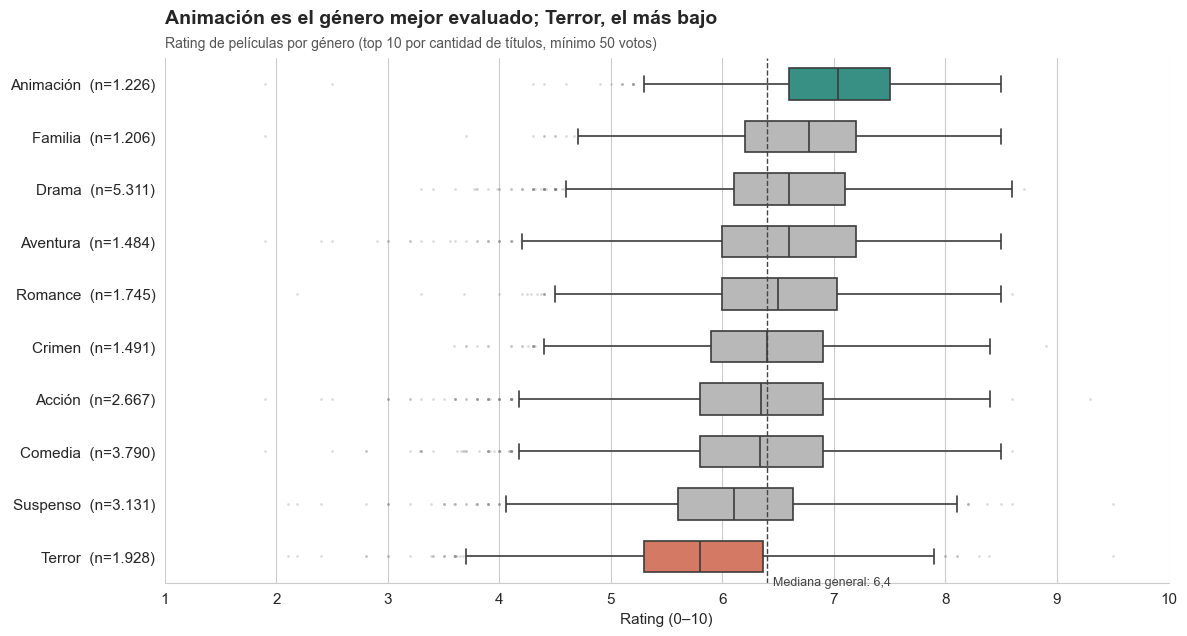

In [17]:
orden = resumen.index.tolist()
mejor, peor = orden[0], orden[-1]
colores = {g: (DESTACADO_BUENO if g == mejor else DESTACADO_MALO if g == peor else GRIS) for g in orden}
mediana_global = movies_an['rating'].median()

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.boxplot(data=df_top, y='genero', x='rating', order=orden, palette=colores,
            orient='h', width=0.6, linewidth=1.2, ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.25, markerfacecolor='#777', markeredgecolor='none'))

ax.axvline(mediana_global, color='#444', linestyle='--', linewidth=1)
ax.text(mediana_global + 0.05, len(orden) - 0.45, f'Mediana general: {mediana_global:.1f}'.replace('.', ','), fontsize=9, color='#444')

ax.set_yticklabels([f'{g}  (n={int(resumen.loc[g, "n"]):,})'.replace(',', '.') for g in orden])
ax.set_title('Animación es el género mejor evaluado; Terror, el más bajo',
             fontsize=14, fontweight='bold', loc='left', pad=25)
ax.text(0, 1.02, f'Rating de películas por género (top 10 por cantidad de títulos, mínimo {MIN_VOTOS} votos)',
        transform=ax.transAxes, fontsize=10, color='#555')
ax.set_xlabel('Rating (0–10)')
ax.set_ylabel('')
ax.set_xlim(1, 10)
ax.grid(axis='y', visible=False)
sns.despine(left=True)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'grafico_1_boxplot_rating_por_genero.png'), dpi=300, bbox_inches='tight')
plt.show()

**¿Por qué un boxplot?**
Queríamos mostrar no solo qué género tiene mejor nota, sino qué tan **consistente** es. El boxplot muestra en un mismo gráfico la mediana (línea al medio de la caja), el rango donde está el 50% central de los títulos (la caja) y los casos extremos (puntos). Un promedio solo no muestra si un género es parejo o si tiene títulos muy buenos mezclados con muy malos.

**Decisiones de diseño:**
- **Ordenado de mayor a menor mediana**, para que la comparación se lea de arriba hacia abajo sin tener que buscar.
- **Todo en gris menos el mejor y el peor género.** El color se usa solo para lo que queremos que el equipo mire. Antes cada caja tenía un color distinto y algunos se repetían, lo que confundía.
- **Línea de referencia con la mediana general**, para ver rápido qué géneros están sobre o bajo el promedio del catálogo.
- **n de cada género en la etiqueta**, para que se vea que las comparaciones se basan en suficientes títulos.
- **Título con la conclusión**, así la audiencia entiende el mensaje aunque solo mire el gráfico unos segundos.

## Gráfico 2 — Barras: % de títulos bien evaluados por género

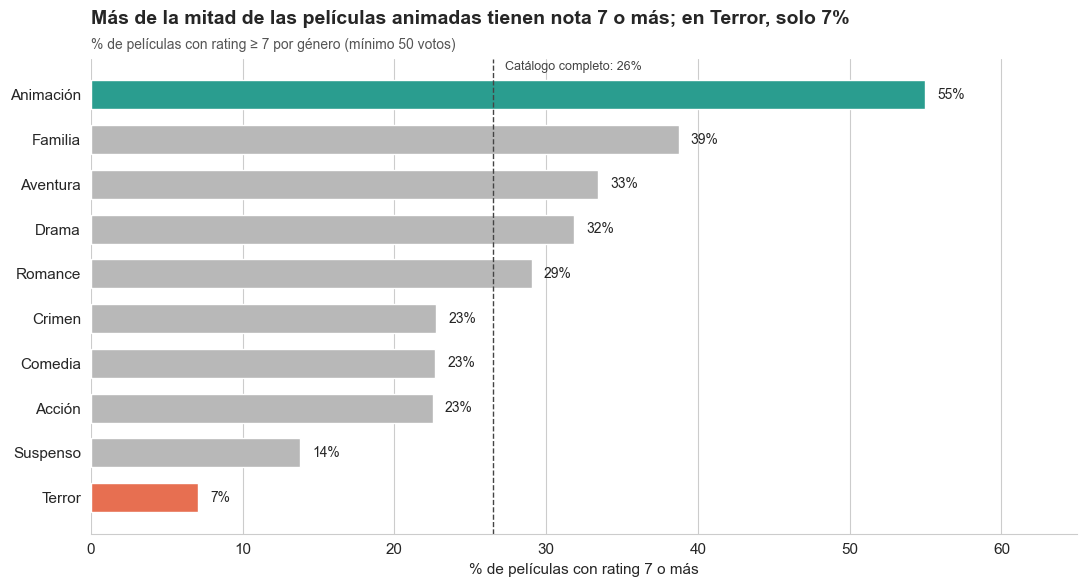

In [18]:
pct = resumen['pct_7_o_mas'].sort_values(ascending=True)
pct_global = (movies_an['rating'] >= 7).mean() * 100
colores_barras = [DESTACADO_BUENO if g == pct.index[-1] else DESTACADO_MALO if g == pct.index[0] else GRIS
                  for g in pct.index]

fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(pct.index, pct.values, color=colores_barras, height=0.65)

for barra, valor in zip(barras, pct.values):
    ax.text(valor + 0.8, barra.get_y() + barra.get_height() / 2, f'{valor:.0f}%',
            va='center', fontsize=10)

ax.axvline(pct_global, color='#444', linestyle='--', linewidth=1)
ax.text(pct_global + 0.8, len(pct) - 0.45, f'Catálogo completo: {pct_global:.0f}%', fontsize=9, color='#444')

ax.set_title(f'Más de la mitad de las películas animadas tienen nota 7 o más; en Terror, solo {pct.iloc[0]:.0f}%',
             fontsize=14, fontweight='bold', loc='left', pad=25)
ax.text(0, 1.02, f'% de películas con rating ≥ 7 por género (mínimo {MIN_VOTOS} votos)',
        transform=ax.transAxes, fontsize=10, color='#555')
ax.set_xlabel('% de películas con rating 7 o más')
ax.set_xlim(0, max(pct.values) + 10)
ax.grid(axis='y', visible=False)
sns.despine(left=True)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'grafico_2_barras_pct_bien_evaluadas.png'), dpi=300, bbox_inches='tight')
plt.show()

**¿Por qué barras horizontales?**
El boxplot es útil para nosotros, pero para alguien de adquisiciones es más directo un número como *"de cada 10 películas de este género, cuántas son buenas"*. Por eso transformamos el rating en un porcentaje de títulos con nota 7 o más (lo usamos como umbral de "bien evaluada").

Las barras son el gráfico más fácil de comparar porque el ojo compara **largos** sobre una misma base, que es más preciso que comparar colores o áreas (como en un gráfico de torta). Van horizontales porque así los nombres de los géneros se leen sin girar la cabeza, y ordenadas para que la jerarquía se vea al tiro. Pusimos el valor al final de cada barra para no tener que leer el eje.

## Gráfico 3 — Líneas: rating de películas vs series a lo largo del tiempo

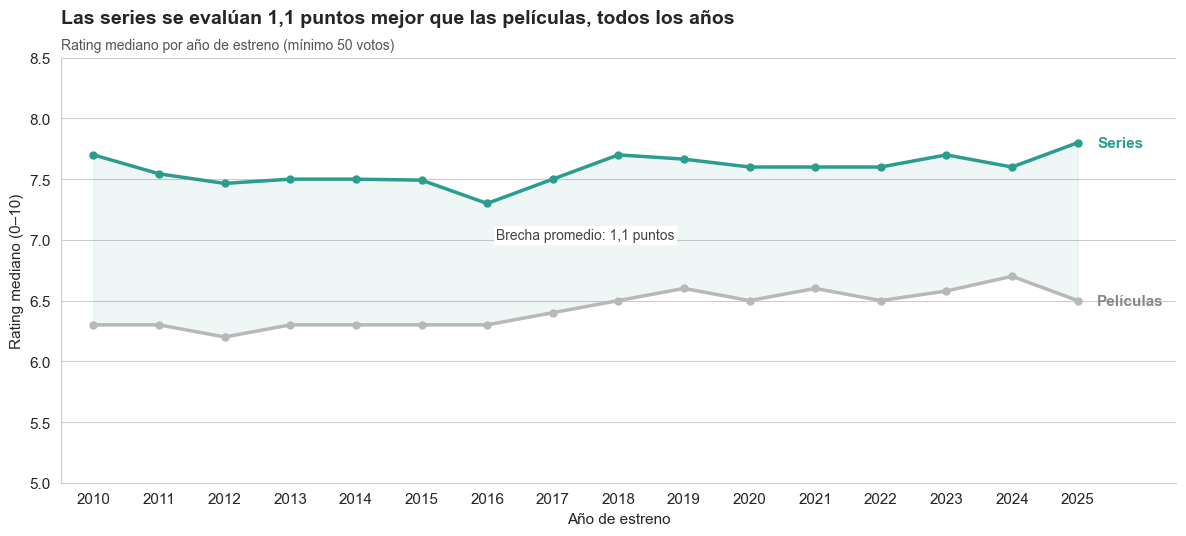

release_year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Películas,6.3,6.30,6.20,6.3,6.3,6.30,6.3,6.4,6.5,6.60,6.5,6.6,6.5,6.58,6.7,6.5
Series,7.7,7.54,7.46,7.5,7.5,7.49,7.3,7.5,7.7,7.66,7.6,7.6,7.6,7.70,7.6,7.8


In [19]:
tendencia = pd.DataFrame({
    'Películas': movies_an.groupby('release_year')['rating'].median(),
    'Series': shows_an.groupby('release_year')['rating'].median(),
})
brecha = (tendencia['Series'] - tendencia['Películas']).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(tendencia.index, tendencia['Series'], color=DESTACADO_BUENO, linewidth=2.5, marker='o', markersize=5)
ax.plot(tendencia.index, tendencia['Películas'], color=GRIS, linewidth=2.5, marker='o', markersize=5)
ax.fill_between(tendencia.index, tendencia['Películas'], tendencia['Series'], color=DESTACADO_BUENO, alpha=0.08)

# Etiquetas directas al final de cada línea (en vez de leyenda)
ultimo = tendencia.index.max()
ax.text(ultimo + 0.3, tendencia.loc[ultimo, 'Series'], 'Series', color=DESTACADO_BUENO, fontweight='bold', va='center')
ax.text(ultimo + 0.3, tendencia.loc[ultimo, 'Películas'], 'Películas', color='#888', fontweight='bold', va='center')
ax.text(2017.5, (tendencia['Series'].mean() + tendencia['Películas'].mean()) / 2,
        f'Brecha promedio: {brecha:.1f} puntos'.replace('.', ','), ha='center', fontsize=10, color='#444',
        bbox=dict(facecolor='white', edgecolor='none', pad=2))

ax.set_title(f'Las series se evalúan {brecha:.1f} puntos mejor que las películas, todos los años'.replace('.', ',', 1),
             fontsize=14, fontweight='bold', loc='left', pad=25)
ax.text(0, 1.02, f'Rating mediano por año de estreno (mínimo {MIN_VOTOS} votos)',
        transform=ax.transAxes, fontsize=10, color='#555')
ax.set_xlabel('Año de estreno')
ax.set_ylabel('Rating mediano (0–10)')
ax.set_ylim(5, 8.5)
ax.set_xlim(tendencia.index.min() - 0.5, ultimo + 1.5)
ax.set_xticks(tendencia.index)
ax.grid(axis='x', visible=False)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'grafico_3_lineas_peliculas_vs_series.png'), dpi=300, bbox_inches='tight')
plt.show()

tendencia.round(2).T

**¿Por qué un gráfico de líneas?**
El año de estreno es una variable ordenada en el tiempo, y la línea es la forma natural de mostrar cómo cambia algo año a año. Con dos líneas se pueden comparar películas y series a la vez y se ve si la diferencia se mantiene o es de un año puntual.

**Decisiones de diseño:**
- **Series en color y películas en gris**, porque el hallazgo es sobre las series.
- **Etiquetas directas al final de cada línea** en vez de leyenda, así no hay que ir y volver para saber qué línea es cuál.
- **El área entre las líneas sombreada** para que la brecha se vea como algo concreto.
- **El eje Y parte en 5 y no en 0.** Lo hicimos a propósito para que se vea la variación entre años. Como lo que comparamos es la distancia entre las dos líneas y no su altura absoluta, no exagera el resultado.
- Usamos la **mediana** y no el promedio porque es menos sensible a los títulos con notas extremas.

# 7. Storytelling: hallazgos principales

In [20]:
# Números que usamos en el relato
print(f'Mediana general películas: {fmt(movies_an["rating"].median(), 1)}')
print(f'% películas con rating ≥ 7: {fmt((movies_an["rating"] >= 7).mean() * 100)}%')
print(f'Mediana general series:    {fmt(shows_an["rating"].median(), 1)}')
print(f'% series con rating ≥ 7:   {fmt((shows_an["rating"] >= 7).mean() * 100)}%\n')
resumen[['n', 'mediana', 'q1', 'q3', 'iqr', 'pct_7_o_mas']].round(2)

Mediana general películas: 6,4
% películas con rating ≥ 7: 26%
Mediana general series:    7,6
% series con rating ≥ 7:   82%



,n,mediana,q1,q3,iqr,pct_7_o_mas
genero,,,,,,
Animación,1226,7.04,6.60,7.50,0.90,54.98
Familia,1206,6.78,6.20,7.20,1.00,38.72
Drama,5311,6.60,6.10,7.10,1.00,31.86
Aventura,1484,6.60,6.00,7.20,1.20,33.42
Romance,1745,6.50,6.00,7.03,1.03,29.05
Crimen,1491,6.40,5.90,6.90,1.00,22.74
Acción,2667,6.34,5.80,6.90,1.10,22.53
Comedia,3790,6.34,5.80,6.90,1.10,22.69
Suspenso,3131,6.10,5.60,6.64,1.04,13.80


### La pregunta
Cuando un usuario entra a StreamView y elige algo para ver, **¿todos los géneros le dan la misma probabilidad de encontrar algo bueno?** Para el equipo de contenidos esto importa, porque si un usuario elige varias veces algo que no le gusta, es más probable que deje de usar la plataforma.

### Hallazgo 1: no todos los géneros son iguales (Gráfico 1)
Analizamos 12.185 películas con al menos 50 votos. La mediana general del catálogo es **6,4**, pero entre géneros hay diferencias claras:
- **Animación** es el mejor evaluado: mediana de **7,0**, y la mitad central de sus películas está entre 6,6 y 7,5. Además es de los más parejos.
- **Familia** (6,8), **Drama** y **Aventura** (6,6) también están sobre la mediana general.
- **Terror** es el más bajo: mediana de **5,8**, con la mitad central entre 5,3 y 6,4. **Suspenso** (6,1) también queda bajo el promedio.

### Hallazgo 2: la diferencia es aún más clara si se mira cuántos títulos son "buenos" (Gráfico 2)
En todo el catálogo, el 26% de las películas tiene nota 7 o más. Pero:
- En **Animación** es el **55%**, más de la mitad.
- En **Terror** es solo el **7%**, o sea, menos de 1 de cada 10.

Un usuario que elige una película animada tiene casi 8 veces más probabilidad de encontrar algo bien evaluado que uno que elige terror.

### Hallazgo 3: las series se evalúan mejor que las películas (Gráfico 3)
Las series con al menos 50 votos tienen una mediana de **7,6** contra **6,4** de las películas, y el **82%** de las series tiene nota 7 o más. La diferencia se mantiene entre 0,9 y 1,4 puntos **todos los años** entre 2010 y 2025, así que no es algo puntual.

Hay que tomarlo con cuidado: solo el 20% de las series llega a 50 votos, así que probablemente estamos viendo las series más conocidas, que suelen ser las que tienen más temporadas y un público más fiel.

### Qué significa para StreamView
Los géneros con ratings bajos no son necesariamente un problema, porque terror y suspenso tienen su público. Pero si el objetivo es que un usuario nuevo encuentre algo bueno rápido, conviene **destacar en la portada y en las recomendaciones los géneros más consistentes** (animación, familia, drama) y ser **más selectivos al adquirir terror y suspenso**, fijándose en títulos que ya vengan con buenas calificaciones.

# 8. Limitaciones del análisis
- El dataset no tiene datos de usuarios (reproducciones, abandono, suscripciones), así que **no podemos medir directamente la retención**. El rating es una aproximación.
- El rating viene de votos públicos, no de usuarios de StreamView.
- Al filtrar por 50 votos dejamos fuera títulos poco conocidos, sobre todo en series (quedan 3.212 de 15.991).
- El dataset tiene 1.000 títulos por año de forma fija, por lo que no sirve para analizar si el catálogo crece.
- Un título puede tener varios géneros, así que una película cuenta en más de un grupo del boxplot.